In [27]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
from typing import Tuple, Sequence, Dict, Union, Optional
import numpy as np
import torch
import torch.nn as nn
import cv2
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from pathlib import Path
import zarr

In [46]:
dataset_path = Path('data/gml_by_drawing_PRESERVE_ASPECT_CENTERED_003000.zarr')
dataset_path = Path('data/gml_by_stroke_PRESERVE_ASPECT_CENTERED_003000.zarr')
dataset_root = zarr.open(dataset_path, 'r')

In [47]:
drawings = dataset_root['data']['state']
episode_ends = dataset_root['meta']['episode_ends']
episode_ends = np.concatenate([[0], episode_ends])
print(drawings.shape, episode_ends.shape)

(2245057, 2) (45084,)


In [48]:
print(np.diff(episode_ends)[:20])

[ 34  54  27  18 101  16  25  11  15 132  24  84  11  14  26  14  23  18
  19  24]


In [53]:
episode_ends.shape

(45084,)

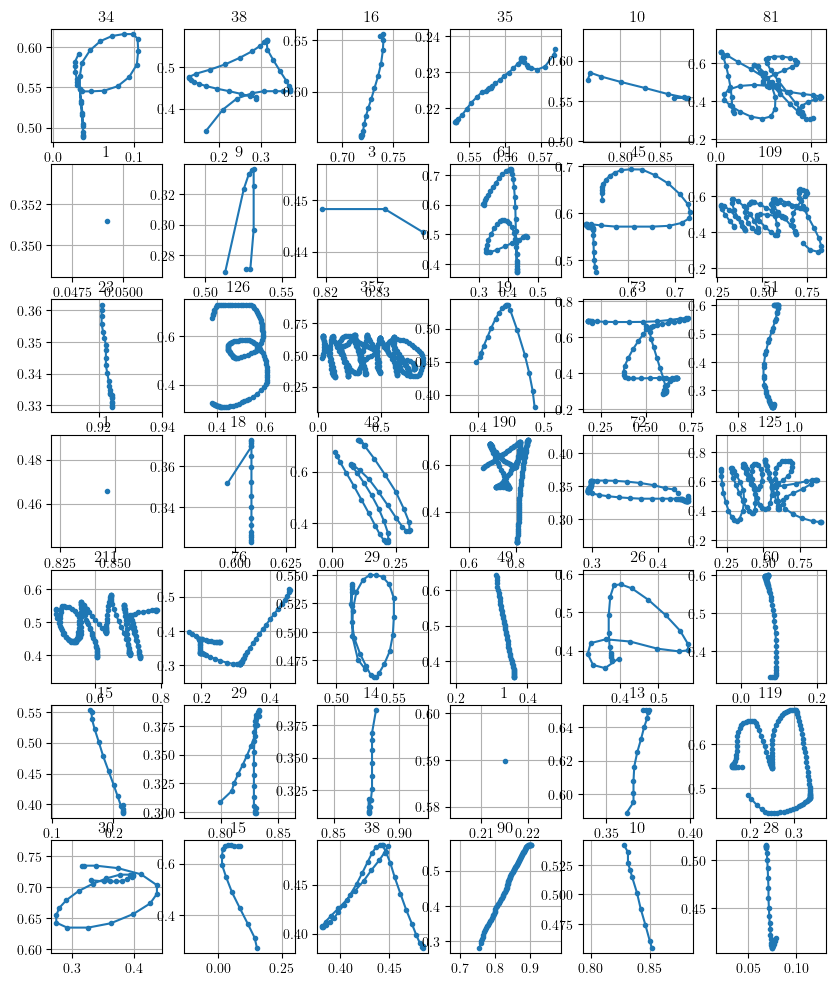

In [63]:
# fig, axes = plt.subplots(5, 8, figsize=(16, 10))
fig, axes = plt.subplots(7, 6, figsize=(10, 12))
for i, ax in enumerate(axes.flat):
    N, M = episode_ends.shape[0], axes.size
    s, e = episode_ends[i*N//M], episode_ends[i*N//M+1]
    ax.plot(*drawings[s:e, :].T, '.-')
    # ax.plot(*drawings[s:e, :].T, '.-', markersize=1, linewidth=0.5)
    # ax.axis('off')
    # ax.set_xlim(0, 1)
    ax.axis('equal')
    ax.set_title(f'{e-s}')